In [66]:
!pip install yfinance

In [67]:
import yfinance as yf

ticker = input("Enter stock ticker (e.g. AAPL, MSFT, TSLA): ").upper()
print(f"Fetching data for {ticker}...")

stock = yf.Ticker(ticker)
cashflow = stock.cashflow
info = stock.info

operating_cf = cashflow.loc["Operating Cash Flow"].iloc[0]
capex = cashflow.loc["Capital Expenditure"].iloc[0]
fcf = operating_cf + capex  # capex is negative so we add

current_price = info["currentPrice"]
shares_outstanding = info["sharesOutstanding"]

print(f"Ticker: {ticker}")
print(f"Current Price: ${current_price}")
print(f"Shares Outstanding: {shares_outstanding:,}")
print(f"Free Cash Flow (latest year): ${fcf:,.0f}")

Enter stock ticker (e.g. AAPL, MSFT, TSLA): AAPL
Fetching data for AAPL...
Ticker: AAPL
Current Price: $298.87
Shares Outstanding: 14,687,356,000
Free Cash Flow (latest year): $98,767,000,000


In [68]:
import requests

# ── FETCH WACC INPUTS ──────────────────────────────────────────

# 1. Beta (market risk of stock vs market)
try:
    beta = info["beta"]
    if beta is None: beta = 1.0
except:
    beta = 1.0
print(f"Beta: {beta:.2f}")

# 2. Risk Free Rate (US 10-year Treasury yield - pulled live)
try:
    treasury = yf.Ticker("^TNX")
    risk_free_rate = treasury.fast_info["lastPrice"] / 100
except:
    risk_free_rate = 0.04  # default 4% if unavailable
print(f"Risk Free Rate: {risk_free_rate:.2%}")

# 3. Market Return (S&P 500 historical average)
market_return = 0.10  # long run S&P 500 average ~10%

# 4. Cost of Equity (CAPM formula)
cost_of_equity = risk_free_rate + beta * (market_return - risk_free_rate)
print(f"Cost of Equity (CAPM): {cost_of_equity:.2%}")

# 5. Cost of Debt
try:
    financials = stock.financials
    interest_expense = None

    # Try each possible label
    for label in ["Interest Expense Non Operating", "Interest Expense"]:
        if label in financials.index:
            val = financials.loc[label].iloc[0]
            if val is not None and str(val) != "nan":
                interest_expense = abs(val)
                break

    total_debt = info.get("totalDebt", None)

    if interest_expense and total_debt and total_debt > 0:
        cost_of_debt = interest_expense / total_debt
        if cost_of_debt > 0.20: cost_of_debt = 0.05
    else:
        cost_of_debt = 0.05
except:
    cost_of_debt = 0.05
print(f"Cost of Debt: {cost_of_debt:.2%}")# 6. Capital Structure Weights
try:
    total_debt = info["totalDebt"]
    market_cap = info["marketCap"]
    total_capital = total_debt + market_cap
    weight_equity = market_cap / total_capital
    weight_debt = total_debt / total_capital
except:
    weight_equity = 0.8  # default 80/20 split if unavailable
    weight_debt = 0.2
print(f"Weight of Equity: {weight_equity:.2%}")
print(f"Weight of Debt:   {weight_debt:.2%}")

# 7. Tax Rate (debt interest is tax deductible)
try:
    tax_rate = info["effectiveTaxRate"]
    if tax_rate is None: tax_rate = 0.21
except:
    tax_rate = 0.21  # US corporate tax rate default
print(f"Tax Rate: {tax_rate:.2%}")

# ── FINAL WACC ─────────────────────────────────────────────────
wacc = (weight_equity * cost_of_equity) + (weight_debt * cost_of_debt * (1 - tax_rate))
print(f"\nCalculated WACC: {wacc:.2%}")



Beta: 1.06
Risk Free Rate: 4.48%
Cost of Equity (CAPM): 10.36%
Cost of Debt: 5.00%
Weight of Equity: 98.11%
Weight of Debt:   1.89%
Tax Rate: 21.00%

Calculated WACC: 10.24%


In [69]:
# ── DCF ASSUMPTIONS (tweak these) ──────────────────────────────
growth_rate      = 0.08   # FCF grows 8% per year for 5 years
terminal_growth  = 0.03   # Growth forever after year 5 (= ~GDP growth)

# Project future FCFs
projected_fcfs = []
for year in range(1, projection_years + 1):
    future_fcf = fcf * (1 + growth_rate) ** year
    projected_fcfs.append(future_fcf)

# Discount each FCF back to today
pv_fcfs = []
for year, future_fcf in enumerate(projected_fcfs, start=1):
    pv = future_fcf / (1 + wacc) ** year
    pv_fcfs.append(pv)

# Terminal Value (Gordon Growth Model)
terminal_value = projected_fcfs[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
pv_terminal_value = terminal_value / (1 + wacc) ** projection_years

# Intrinsic Value per Share
enterprise_value = sum(pv_fcfs) + pv_terminal_value
intrinsic_value_per_share = enterprise_value / shares_outstanding

print(f"Sum of PV of FCFs:        ${sum(pv_fcfs):,.0f}")
print(f"PV of Terminal Value:     ${pv_terminal_value:,.0f}")
print(f"Enterprise Value:         ${enterprise_value:,.0f}")
print(f"Intrinsic Value Per Share:${intrinsic_value_per_share:.2f}")
print(f"Current Market Price:     ${current_price}")
print(f"\nVerdict: {'UNDERVALUED 🟢' if intrinsic_value_per_share > current_price else 'OVERVALUED 🔴'}")

Sum of PV of FCFs:        $464,567,505,232
PV of Terminal Value:     $1,268,646,002,180
Enterprise Value:         $1,733,213,507,413
Intrinsic Value Per Share:$118.01
Current Market Price:     $298.87

Verdict: OVERVALUED 🔴


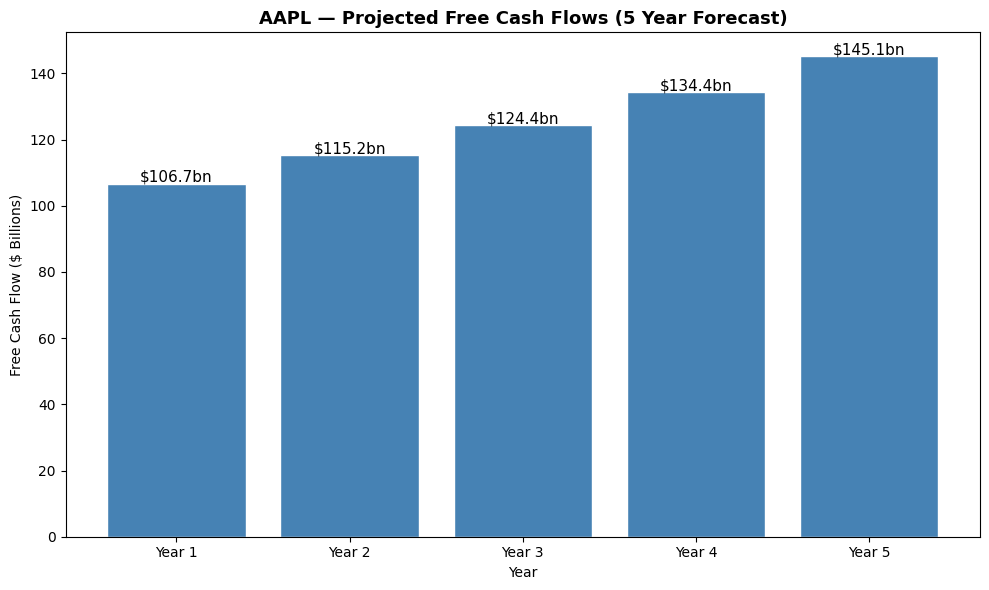

Chart saved as AAPL_projected_fcf.png


In [70]:
# Bar chart of projected FCFs
years = [f"Year {i}" for i in range(1, projection_years + 1)]

plt.figure(figsize=(10, 6))
bars = plt.bar(years, [fcf/1e9 for fcf in projected_fcfs], color="steelblue", edgecolor="white")

# Add value labels on top of each bar
for bar, value in zip(bars, projected_fcfs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"${value/1e9:.1f}bn",
             ha="center", fontsize=11)

plt.title(f"{ticker} — Projected Free Cash Flows (5 Year Forecast)", fontsize=13, fontweight="bold")
plt.ylabel("Free Cash Flow ($ Billions)")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig(f"{ticker}_projected_fcf.png", dpi=150)
plt.show()

print(f"Chart saved as {ticker}_projected_fcf.png")

In [71]:
print("=" * 55)
print(f"  DCF VALUATION SUMMARY — {ticker}")
print("=" * 55)
print(f"  Current Market Price:      ${current_price:>10.2f}")
print(f"  Intrinsic Value Per Share: ${intrinsic_value_per_share:>10.2f}")
print(f"  Upside / Downside:         {((intrinsic_value_per_share - current_price) / current_price * 100):>+10.1f}%")
print("-" * 55)
print(f"  FCF (Latest Year):         ${fcf/1e9:>10.2f}bn")
print(f"  Enterprise Value:          ${enterprise_value/1e9:>10.2f}bn")
print(f"  PV of Terminal Value:      ${pv_terminal_value/1e9:>10.2f}bn")
print("-" * 55)
print(f"  Assumptions:")
print(f"    FCF Growth Rate:         {growth_rate:.0%}")
print(f"    WACC:                    {wacc:.0%}")
print(f"    Terminal Growth Rate:    {terminal_growth:.0%}")
print("=" * 55)
verdict = "UNDERVALUED 🟢" if intrinsic_value_per_share > current_price else "OVERVALUED 🔴"
print(f"  Verdict: {verdict}")
print("=" * 55)

  DCF VALUATION SUMMARY — AAPL
  Current Market Price:      $    298.87
  Intrinsic Value Per Share: $    118.01
  Upside / Downside:              -60.5%
-------------------------------------------------------
  FCF (Latest Year):         $     98.77bn
  Enterprise Value:          $   1733.21bn
  PV of Terminal Value:      $   1268.65bn
-------------------------------------------------------
  Assumptions:
    FCF Growth Rate:         8%
    WACC:                    10%
    Terminal Growth Rate:    3%
  Verdict: OVERVALUED 🔴


In [72]:
import pandas as pd

# Ranges to test
wacc_range   = [0.07, 0.08, 0.09, 0.10, 0.11]
growth_range = [0.05, 0.06, 0.07, 0.08, 0.09]

# Build the table
table = {}
for g in growth_range:
    row = {}
    for w in wacc_range:
        # Rerun DCF with these assumptions
        p_fcfs = [fcf * (1 + g) ** yr for yr in range(1, projection_years + 1)]
        pv     = [p_fcfs[yr-1] / (1 + w) ** yr for yr in range(1, projection_years + 1)]
        tv     = p_fcfs[-1] * (1 + terminal_growth) / (w - terminal_growth)
        pv_tv  = tv / (1 + w) ** projection_years
        iv     = (sum(pv) + pv_tv) / shares_outstanding
        row[f"WACC {w:.0%}"] = round(iv, 2)
    table[f"Growth {g:.0%}"] = row

df = pd.DataFrame(table).T
print("Intrinsic Value Per Share — Sensitivity Table")
print(df.to_string())
print(f"\nCurrent Market Price: ${current_price}")

Intrinsic Value Per Share — Sensitivity Table
           WACC 7%  WACC 8%  WACC 9%  WACC 10%  WACC 11%
Growth 5%   189.35   151.25   125.85    107.72     94.12
Growth 6%   197.91   157.97   131.35    112.35     98.10
Growth 7%   206.78   164.93   137.05    117.14    102.22
Growth 8%   215.98   172.15   142.95    122.11    106.49
Growth 9%   225.51   179.63   149.06    127.25    110.90

Current Market Price: $298.87


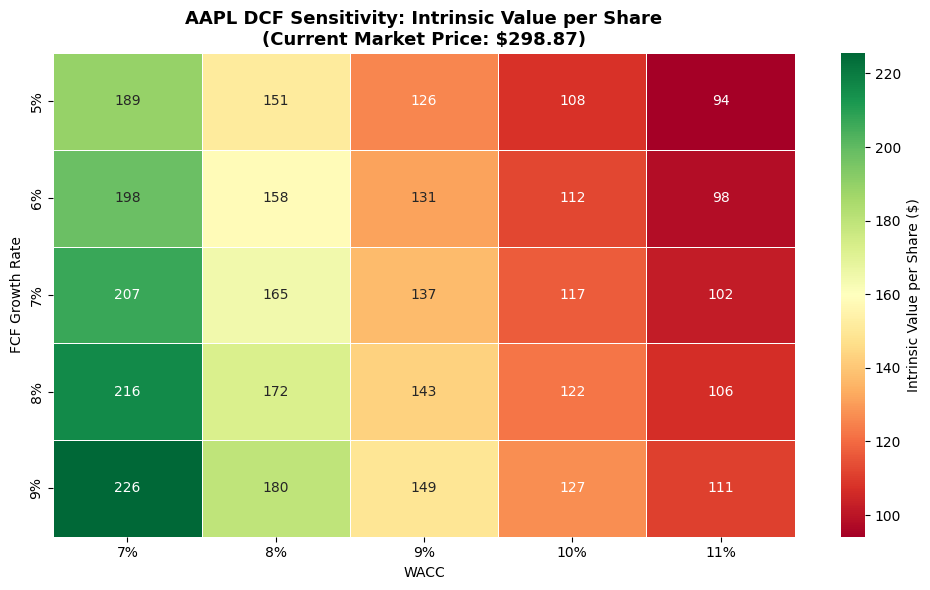

Chart saved as AAPL_dcf_sensitivity.png


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to numeric for heatmap
heatmap_data = df.copy()
heatmap_data.columns = [c.replace("WACC ", "") for c in heatmap_data.columns]
heatmap_data.index = [i.replace("Growth ", "") for i in heatmap_data.index]

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data.astype(float),
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",       # Red = low value, Green = high value
    linewidths=0.5,
    cbar_kws={"label": "Intrinsic Value per Share ($)"}
)

# Add a line showing current market price context
plt.title(f"{ticker} DCF Sensitivity: Intrinsic Value per Share\n(Current Market Price: ${current_price})",
          fontsize=13, fontweight="bold")
plt.xlabel("WACC")
plt.ylabel("FCF Growth Rate")
plt.tight_layout()
plt.savefig(f"{ticker}_dcf_sensitivity.png", dpi=150)  # saves the chart
plt.show()

print(f"Chart saved as {ticker}_dcf_sensitivity.png")